[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/04_machine_learning/A2_pytorch_vision_and_sequences.ipynb)

> 📎 **Appendix notebook — reference style.** This is one of the optional appendices (see `README.md`). Unlike the main course notebooks, appendices are written as a demo / reference: they focus on *seeing* a library at work rather than on interactive exercises. You won't find the full Solution / Debug-me / Self-assessment scaffolding here. Each appendix is built to run end-to-end *without* the optional library — it falls back to a small built-in stand-in (or skips the library-specific cells), so you can read and run it offline. Install the optional library (see the **Install** section below) to swap the stand-in for the real thing.

---
# 📓 Notebook A2 (ML) — PyTorch: Vision & Sequences

> **Module:** Machine Learning · **Type:** Appendix · **Estimated time:** 60–90 min · **Difficulty:** Advanced

Notebook A1 covered the foundations and trained an MLP on tabular data. Now we step into the two most-used architectural families:

1. **CNNs** for grid-structured data (images, audio spectrograms).
2. **RNNs and a small Transformer** for sequence-structured data (text, time series, logs).

You'll train a tiny CNN on a toy image dataset and a tiny Transformer on a synthetic sequence task — both small enough to run on a laptop CPU in under a minute.

---

## 🎯 Learning objectives
- Build a CNN (`Conv2d → ReLU → Pool → Conv2d → … → Linear`) for image classification.
- Build an RNN (LSTM) for sequence classification.
- Build a tiny Transformer encoder and understand each block (self-attention, FFN, residual, layer-norm).
- Pick between RNN and Transformer for a given sequence task.

## ✅ Prerequisites
- Notebook A1 (PyTorch foundations).
- Notebook 16 if you want the feature-engineering context (optional).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import TensorDataset, DataLoader
    HAS_TORCH = True
    torch.manual_seed(0)
    print(f"PyTorch {torch.__version__}")
except Exception as e:
    HAS_TORCH = False
    print("PyTorch not installed —", e)


PyTorch 2.12.0


## 1. Convolutional networks — the image workhorse

A 2-D convolution slides a small filter across the image and produces a *feature map*. Stacking conv layers grows the *receptive field* — early layers respond to edges, deeper layers to whole objects.

```
Image  →  [Conv 3×3 → ReLU → MaxPool 2×2]  ×N  →  Flatten  →  Linear  →  logits
```

### A toy dataset — synthetic 8×8 "digits"


### 🔬 What a convolution *actually* computes

Before we trust `nn.Conv2d` as a black box, let's open it up. A 2-D convolution is much simpler than the name suggests — there is no calculus, no integrals. It is just a **tiny grid of weights (a *kernel*) that you slide over the image, computing one dot product at each stop.**

**The kernel.** Say the kernel is 3×3. That's just 9 numbers arranged in a square — a little "stencil":

```text
kernel  (3×3, the learned weights)
 +----+----+----+
 | -1 |  0 | +1 |
 +----+----+----+        ← this particular stencil is a
 | -1 |  0 | +1 |          vertical-edge detector: it fires
 +----+----+----+          POSITIVE where the image goes
 | -1 |  0 | +1 |          dark→bright left-to-right
 +----+----+----+
```

**One output pixel = one dot product.** Lay the kernel over a 3×3 *patch* of the image. Multiply each kernel weight by the pixel underneath it, then sum all 9 products. That single number is **one** pixel of the output. Move the kernel one step right and repeat. That's the whole algorithm.

**Sliding the stencil.** The kernel starts in the top-left corner, dot-products the overlapping patch, then slides right one column, then down one row — visiting every position where it fully fits:

```text
 input 5×5                 step 1: kernel over            step 2: slide right
 (· = a pixel)             the TOP-LEFT 3×3 patch         by one column
 · · · · ·                 ┌───────┐                        ┌───────┐
 · · · · ·                 │█ █ █│· ·   → out[0,0]        ·│█ █ █│·   → out[0,1]
 · · · · ·                 │█ █ █│· ·                     ·│█ █ █│·
 · · · · ·                 │█ █ █│· ·                     ·│█ █ █│·
 · · · · ·                 └───────┘· ·                   · └───────┘·
                           the 9 boxed pixels             window moved one step;
                           are dot-producted with         same 9 weights reused
                           the 9 kernel weights           → one new output pixel
```

> 🧠 **Shared weights — the key idea.** The *same* 9 kernel numbers are reused at **every** position. The network does not learn a separate detector per location; it learns *one* small pattern-detector and applies it everywhere. That's why CNNs (1) have very few parameters, and (2) are **translation-aware**: a vertical edge is detected the same way whether it's on the left of the image or the right.

### 🧪 Proof: compute one output pixel by hand, then match `conv2d`

We'll build a tiny 5×5 input with a bright square in the middle, take the vertical-edge kernel above, compute the **top-left output pixel by hand** (numpy `sum` of the elementwise product), and confirm `torch.nn.functional.conv2d` produces the exact same full feature map.

In [2]:
import numpy as np
import torch
import torch.nn.functional as F

# A tiny 5×5 "image": flat border, bright 3×3 square in the middle.
img = np.array([
    [0, 0, 0, 0, 0],
    [0, 9, 9, 9, 0],
    [0, 9, 9, 9, 0],
    [0, 9, 9, 9, 0],
    [0, 0, 0, 0, 0],
], dtype=np.float32)

# A 3×3 vertical-edge detector (the stencil drawn above).
kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
], dtype=np.float32)

# ── BY HAND: the top-left output pixel ──────────────────────────────
# Lay the kernel over the top-left 3×3 patch, multiply element-by-element,
# then sum all 9 products. That single number is output[0, 0].
patch = img[0:3, 0:3]                 # the 3×3 region under the kernel
products = patch * kernel             # elementwise multiply (9 numbers)
by_hand = products.sum()              # add them up → ONE output pixel

print("patch under kernel:\n", patch)
print("elementwise products:\n", products)
print("by-hand output[0,0] =", by_hand)      # 18.0

patch under kernel:
 [[0. 0. 0.]
 [0. 9. 9.]
 [0. 9. 9.]]
elementwise products:
 [[-0.  0.  0.]
 [-0.  0.  9.]
 [-0.  0.  9.]]
by-hand output[0,0] = 18.0


In [3]:
# ── VIA conv2d: the WHOLE feature map at once ───────────────────────
# torch.nn.functional.conv2d expects 4-D tensors:
#   input  : (batch, in_channels,  H, W)
#   weight : (out_channels, in_channels, kH, kW)
# Our single image / single kernel → add those size-1 dimensions with [None, None].
img_t    = torch.from_numpy(img)[None, None]      # shape (1, 1, 5, 5)
kernel_t = torch.from_numpy(kernel)[None, None]   # shape (1, 1, 3, 3)

feature_map = F.conv2d(img_t, kernel_t)           # no padding (default)
fm = feature_map[0, 0].numpy()                    # drop batch/channel dims

print("full feature map (conv2d):\n", fm)
print("conv2d output[0,0] =", fm[0, 0])

# 1️⃣ The hand-computed pixel matches conv2d's top-left pixel EXACTLY:
assert np.isclose(by_hand, fm[0, 0]), "by-hand and conv2d disagree!"

# 2️⃣ Reproduce the ENTIRE map by sliding the kernel ourselves — must match conv2d:
out_h, out_w = 5 - 3 + 1, 5 - 3 + 1                # = 3, 3   (see size rule below)
manual = np.zeros((out_h, out_w), dtype=np.float32)
for r in range(out_h):
    for c in range(out_w):
        manual[r, c] = (img[r:r+3, c:c+3] * kernel).sum()   # dot-product at (r,c)
assert np.allclose(manual, fm), "manual slide and conv2d disagree!"

print("\n✅ by-hand pixel, manual full slide, and conv2d all agree.")

full feature map (conv2d):
 [[ 18.   0. -18.]
 [ 27.   0. -27.]
 [ 18.   0. -18.]]
conv2d output[0,0] = 18.0

✅ by-hand pixel, manual full slide, and conv2d all agree.


### Why the output is *smaller* than the input

Notice the input was **5×5** but the feature map is **3×3**. That's not a bug — it's geometry. The 3×3 kernel must fit *entirely* inside the image, so its top-left corner can only sit at positions 0, 1, 2 along each axis (3 valid spots), not 0–4. The general rule with no padding:

```text
output_size = input_size − kernel_size + 1
            =     5      −      3       + 1  =  3
```

Every conv layer shrinks the image by `kernel_size − 1` on each axis. To **keep** the size, you pad the border with zeros — exactly what `padding=1` does for a 3×3 kernel in the `TinyCNN` model below (it adds a 1-pixel zero border so `5×5 → 5×5`).

> 🎯 **Mental model.** *A convolution = slide a small weight-stencil over the image, dot-producting at every spot.* The **same** stencil is reused everywhere (shared weights), so one learned 3×3 pattern — an edge, a corner, a texture — is detected across the whole image. Training just adjusts those 9 (× channels) numbers so the stencils learn the patterns that help the task.

> ⚠️ **Heads-up on a name.** What deep-learning libraries call "convolution" is technically **cross-correlation** (the kernel is *not* flipped). It makes zero difference in practice — the weights are learned either way — but it's why our plain elementwise `patch * kernel` matched `conv2d` with no flipping needed.

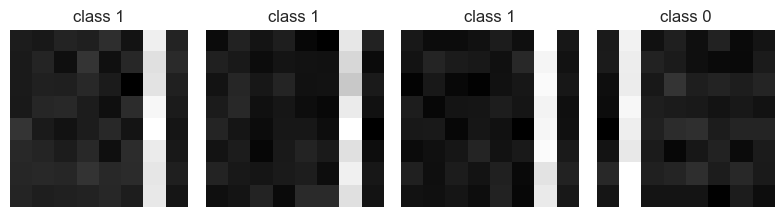

In [4]:
# Build a toy dataset: 8×8 grids with one of two patterns (left-bar vs right-bar).
def make_toy_images(n=1000, seed=0):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, 1, 8, 8), dtype=np.float32)
    y = rng.integers(0, 2, size=n)
    for i, yi in enumerate(y):
        X[i, 0] = rng.normal(0, 0.05, (8, 8))
        col = 1 if yi == 0 else 6
        X[i, 0, :, col] += 1.0     # bright vertical bar at left or right
    return X, y.astype(np.int64)

Xtr_np, ytr_np = make_toy_images(800, seed=0)
Xte_np, yte_np = make_toy_images(200, seed=1)

fig, axes = plt.subplots(1, 4, figsize=(8, 2.2))
for ax, im, lbl in zip(axes, Xtr_np[:4], ytr_np[:4]):
    ax.imshow(im[0], cmap="gray"); ax.set_title(f"class {lbl}"); ax.axis("off")
plt.tight_layout(); plt.show()


In [5]:
if HAS_TORCH:
    class TinyCNN(nn.Module):
        def __init__(self, n_classes=2):
            super().__init__()
            self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
            self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
            self.pool  = nn.MaxPool2d(2, 2)
            self.fc    = nn.Linear(16 * 2 * 2, n_classes)
        def forward(self, x):
            x = self.pool(F.relu(self.conv1(x)))     # → 8×4×4
            x = self.pool(F.relu(self.conv2(x)))     # → 16×2×2
            x = x.flatten(1)
            return self.fc(x)

    cnn = TinyCNN()
    print(cnn); print("params:", sum(p.numel() for p in cnn.parameters()))

    Xtr = torch.from_numpy(Xtr_np); ytr = torch.from_numpy(ytr_np)
    Xte = torch.from_numpy(Xte_np); yte = torch.from_numpy(yte_np)
    dl_tr = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)

    opt = torch.optim.Adam(cnn.parameters(), lr=3e-3)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(8):
        cnn.train()
        for xb, yb in dl_tr:
            opt.zero_grad(); loss_fn(cnn(xb), yb).backward(); opt.step()
        cnn.eval()
        with torch.no_grad():
            acc = (cnn(Xte).argmax(1) == yte).float().mean().item()
        print(f"epoch {epoch}  test acc {acc:.3f}")


TinyCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)
params: 1378


epoch 0  test acc 1.000
epoch 1  test acc 1.000
epoch 2  test acc 1.000
epoch 3  test acc 1.000
epoch 4  test acc 1.000
epoch 5  test acc 1.000
epoch 6  test acc 1.000
epoch 7  test acc 1.000


**Why a CNN beats an MLP on images.** A CNN reuses the same filter at every location (*weight sharing*) and so has dramatically fewer parameters for the same expressive power. The locality assumption (nearby pixels matter together) is *baked into the architecture*.

For real datasets — CIFAR-10, ImageNet — use a pretrained backbone like `torchvision.models.resnet18(weights="DEFAULT")` and fine-tune. A3 walks through the fine-tuning recipe (on a small text transformer, but the freeze-the-body / train-the-head idea is identical).


---

### ✋ Quick exercise (~2 min) — Predict the feature-map size

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

A new image classifier stacks one `nn.Conv2d(1, 4, kernel_size=3)` (no padding) then `nn.MaxPool2d(2, 2)` on a `1×8×8` input. Using the size rule from this section, work out the conv output spatial size, the size after pooling, and the flattened length that would feed a final `Linear`.

```python
in_size, kernel, pool, out_channels = 8, 3, 2, 4
```

In [ ]:
# ✍️ Your turn 👇
in_size, kernel, pool, out_channels = 8, 3, 2, 4

# 1) conv output H/W with NO padding:  in_size - kernel + 1
# 2) after MaxPool2d(2, 2):  integer-divide by 2
# 3) flattened length feeding the Linear:  out_channels * H * W
conv_hw  = ...
pool_hw  = ...
flat_len = ...
print(conv_hw, pool_hw, flat_len)

<details>
<summary>✅ <b>Solution</b></summary>

```python
conv_hw = 8 - 3 + 1            # = 6   (input − kernel + 1, no padding)
pool_hw = conv_hw // 2         # = 3   (2×2 max-pool halves each axis)
flat_len = 4 * pool_hw * pool_hw   # = 36  (channels × H × W)
print(conv_hw, pool_hw, flat_len)  # 6 3 36

# Verify with torch:
if HAS_TORCH:
    net = nn.Sequential(nn.Conv2d(1, 4, kernel_size=3), nn.MaxPool2d(2, 2))
    print(net(torch.zeros(1, 1, 8, 8)).shape)   # torch.Size([1, 4, 3, 3])
```

A no-padding 3×3 conv shrinks 8→6 (`input − kernel + 1`), the 2×2 pool halves 6→3, so the 4×3×3 feature map flattens to 4·3·3 = 36 values feeding the final `Linear`.
</details>

## 2. RNNs — the canonical sequence model

A recurrent layer maintains a hidden state $h_t$ that gets updated as it consumes a sequence:

$$
h_t = f(W_x x_t + W_h h_{t-1} + b)
$$

LSTMs and GRUs are the variants you'll actually use — they have gating that fixes vanishing-gradient issues.

### Toy task — classify whether a sum exceeds a threshold

Each sample is a length-20 sequence of random numbers; the label is 1 if the sequence's total sum exceeds a cut-off.


In [6]:
def make_seq_data(n=2000, L=20, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, (n, L, 1)).astype(np.float32)
    y = (X.sum(axis=1).squeeze() > 1.5).astype(np.int64)
    return X, y

Xtr_np, ytr_np = make_seq_data(2000, seed=0)
Xte_np, yte_np = make_seq_data(500,  seed=1)
print("balance — train:", float(ytr_np.mean()), "test:", float(yte_np.mean()))


balance — train: 0.3775 test: 0.354


In [7]:
if HAS_TORCH:
    class TinyLSTM(nn.Module):
        def __init__(self, input_dim=1, hidden=32, n_classes=2):
            super().__init__()
            self.lstm = nn.LSTM(input_dim, hidden, batch_first=True)
            self.fc   = nn.Linear(hidden, n_classes)
        def forward(self, x):
            out, (h, c) = self.lstm(x)     # out: (B, L, H), h: (1, B, H)
            return self.fc(h[-1])          # use the final hidden state

    Xtr = torch.from_numpy(Xtr_np); ytr = torch.from_numpy(ytr_np)
    Xte = torch.from_numpy(Xte_np); yte = torch.from_numpy(yte_np)
    dl_tr = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)

    rnn = TinyLSTM()
    opt = torch.optim.Adam(rnn.parameters(), lr=3e-3)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(8):
        rnn.train()
        for xb, yb in dl_tr:
            opt.zero_grad(); loss_fn(rnn(xb), yb).backward(); opt.step()
        rnn.eval()
        with torch.no_grad():
            acc = (rnn(Xte).argmax(1) == yte).float().mean().item()
        print(f"epoch {epoch}  test acc {acc:.3f}")


epoch 0  test acc 0.860
epoch 1  test acc 0.918
epoch 2  test acc 0.944


epoch 3  test acc 0.968
epoch 4  test acc 0.956


epoch 5  test acc 0.960
epoch 6  test acc 0.980
epoch 7  test acc 0.970


**Things to know about RNNs**

| Concept | Detail |
|---|---|
| `batch_first=True` | inputs are `(batch, seq, features)`. Off by default — set it! |
| Variable-length sequences | Use `nn.utils.rnn.pack_padded_sequence` |
| Bidirectional | `nn.LSTM(..., bidirectional=True)` doubles the hidden output |
| Truncated BPTT | For very long sequences, detach hidden state across chunks |

⚠️ **Why people moved to Transformers.** RNNs process sequences left-to-right, so they can't be parallelised over time. Transformers compute attention over all positions in parallel — orders of magnitude faster on modern hardware.


## 3. A tiny Transformer encoder

A Transformer block is:

```
x → MultiHeadAttention(x, x, x) → Add & LayerNorm → FFN → Add & LayerNorm
```

`nn.TransformerEncoderLayer` packages this. We just need to add positional encodings and a classification head.


In [8]:
if HAS_TORCH:
    class PositionalEncoding(nn.Module):
        def __init__(self, d_model, max_len=128):
            super().__init__()
            pe = torch.zeros(max_len, d_model)
            position = torch.arange(0, max_len).unsqueeze(1)
            div = torch.exp(torch.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
            pe[:, 0::2] = torch.sin(position * div)
            pe[:, 1::2] = torch.cos(position * div)
            self.register_buffer("pe", pe)
        def forward(self, x):
            return x + self.pe[: x.size(1)].unsqueeze(0)

    class TinyTransformer(nn.Module):
        def __init__(self, input_dim=1, d_model=32, n_heads=4, n_layers=2, n_classes=2, max_len=64):
            super().__init__()
            self.proj  = nn.Linear(input_dim, d_model)
            self.pe    = PositionalEncoding(d_model, max_len=max_len)
            layer      = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=64,
                                                    dropout=0.1, batch_first=True, activation="relu")
            self.enc   = nn.TransformerEncoder(layer, num_layers=n_layers)
            self.head  = nn.Linear(d_model, n_classes)
        def forward(self, x):
            x = self.pe(self.proj(x))           # (B, L, d_model)
            x = self.enc(x)                      # (B, L, d_model)
            return self.head(x.mean(dim=1))     # pool by averaging across sequence

    tx = TinyTransformer()
    print("params:", sum(p.numel() for p in tx.parameters()))

    opt = torch.optim.Adam(tx.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(8):
        tx.train()
        for xb, yb in dl_tr:
            opt.zero_grad(); loss_fn(tx(xb), yb).backward(); opt.step()
        tx.eval()
        with torch.no_grad():
            acc = (tx(Xte).argmax(1) == yte).float().mean().item()
        print(f"epoch {epoch}  test acc {acc:.3f}")


params: 17218


epoch 0  test acc 0.880


epoch 1  test acc 0.942


epoch 2  test acc 0.986


epoch 3  test acc 0.964


epoch 4  test acc 0.988


epoch 5  test acc 0.992


epoch 6  test acc 0.968


epoch 7  test acc 0.982


**What the encoder block actually does**

`MultiHeadAttention(x, x, x)` — for each token, compute a weighted sum of *all* other tokens, where the weight is a learned similarity (the *attention score*). The three `x`s are queries, keys, values — *all the same* in self-attention.

`Add & LayerNorm` — the residual connection is what makes deep stacks trainable. Layer-norm stabilises the activations.

`FFN` — a two-layer MLP applied independently per position. This is where most of the parameters live in a typical Transformer.

**Receptive field.** A 2-layer encoder already has *global* receptive field (any token can attend to any other in one step). Compare to a CNN where you need many layers.


---

### ✋ Quick exercise (~2 min) — Read the LSTM's output shapes

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

A demand-forecasting model uses a bare `nn.LSTM(1, 16, batch_first=True)` fed a batch of 5 series, each 7 steps long, 1 feature. Before running it, predict the shapes of the two returned objects — the per-step output `out` and the final hidden state `h` — then confirm. (Recall the LSTM model above used `h[-1]` for classification.)

In [ ]:
# ✍️ Your turn 👇
if HAS_TORCH:
    lstm = nn.LSTM(1, 16, batch_first=True)
    x = torch.randn(5, 7, 1)          # 5 sequences, 7 steps, 1 feature
    out, h = ..., ...                  # run lstm(x); grab the per-step output and final hidden state
    print(out, h)                      # then inspect out.shape and h.shape
else:
    print("Skipped — torch not installed.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    lstm = nn.LSTM(1, 16, batch_first=True)
    out, (h, c) = lstm(torch.randn(5, 7, 1))
    print(out.shape, h.shape)   # torch.Size([5, 7, 16])  torch.Size([1, 5, 16])
else:
    print("Skipped — torch not installed.")
```

With `batch_first=True`, `out` is `(batch, seq, hidden) = (5, 7, 16)` — one vector per timestep — while `h` is `(num_layers, batch, hidden) = (1, 5, 16)`, the final state; the classifier reads `h[-1]`.
</details>

## 4. RNN vs Transformer — pick the right tool

| Criterion | LSTM/GRU | Transformer |
|---|---|---|
| Sequence length | OK to ~1000 | Excellent (with attention masks, FlashAttention, etc.) |
| Parallelism in training | Sequential | Parallel across positions |
| Inductive bias | Order matters, recent context emphasised | None until you add positional encodings |
| Sample efficiency on small data | Often better | Worse without pretraining |
| Hardware match (GPUs/TPUs) | Mediocre | Excellent |

**Heuristic.** Small dataset, < 100 timesteps → LSTM is fine. Lots of data, long sequences, GPU available → Transformer. Pretrained model in the wild → almost certainly a Transformer.


---
## 5. Data augmentation — the cheapest accuracy you'll ever buy

On images, the fastest way to fight overfitting isn't a bigger model — it's **more (synthetic) data**. Random flips, crops, rotations and colour jitter teach the network that *a cat is still a cat when it's shifted three pixels left*. In `torchvision` this is a one-liner pipeline applied **on the fly** during training (never to the validation/test set):

```python
from torchvision import transforms
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([           # deterministic — NO random ops on eval data
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
```

The cell below shows what augmentation *does* to a single tensor "image" using only PyTorch ops, so it runs without `torchvision`.

In [ ]:
if HAS_TORCH:
    torch.manual_seed(0)
    # A fake 1x16x16 "image": a bright square on a dark field.
    img = torch.zeros(1, 16, 16); img[:, 4:12, 4:12] = 1.0

    def random_hflip(t):           # mirror left<->right
        return torch.flip(t, dims=[-1]) if torch.rand(1).item() < 0.5 else t
    def random_shift(t, max_px=3):  # roll a few pixels (a poor-man's crop/translate)
        dx, dy = torch.randint(-max_px, max_px + 1, (2,)).tolist()
        return torch.roll(t, shifts=(dy, dx), dims=(-2, -1))
    def jitter(t, sigma=0.1):       # brightness/contrast noise
        return (t + sigma * torch.randn_like(t)).clamp(0, 1)

    aug = [jitter(random_shift(random_hflip(img))) for _ in range(4)]
    fig, axes = plt.subplots(1, 5, figsize=(11, 2.4))
    axes[0].imshow(img[0], cmap="gray"); axes[0].set_title("original")
    for ax, a in zip(axes[1:], aug):
        ax.imshow(a[0], cmap="gray"); ax.set_title("augmented")
    for ax in axes: ax.axis("off")
    plt.tight_layout(); plt.show()
    print("Each epoch the model sees a *different* version — so it can't memorise pixels.")
else:
    print("Skipped — torch not installed.")

---

### ✋ Quick exercise (~2 min) — Add a vertical-flip augmentation

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

A document-scan classifier sometimes receives pages fed in upside-down. Following the `random_hflip` pattern above (which used `torch.flip`), write `random_vflip(t)` that flips a `(1, H, W)` image top-to-bottom with probability 0.5.

In [ ]:
# ✍️ Your turn 👇
if HAS_TORCH:
    def random_vflip(t):
        return t   # TODO: flip top<->bottom with probability 0.5 (mirror of random_hflip)

    img = torch.zeros(1, 8, 8); img[:, :2, :] = 1.0   # bright stripe along the TOP
    print(random_vflip(img)[0])
else:
    print("Skipped — torch not installed.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    def random_vflip(t):
        return torch.flip(t, dims=[-2]) if torch.rand(1).item() < 0.5 else t
else:
    print("Skipped — torch not installed.")
```

`dims=[-2]` is the height axis, so flipping there mirrors top↔bottom — exactly mirroring `random_hflip`, which used `dims=[-1]` (the width axis). The coin-flip with `torch.rand(1) < 0.5` applies it only half the time.
</details>

## 6. Transfer learning for vision — don't train from scratch

You almost never train a vision model from random weights. You take a network **pretrained on ImageNet** (1.2M images), freeze its feature extractor, and retrain only a new classification head on your few thousand images. This is the §A3 fine-tuning idea, applied to pixels. The whole move is ~8 lines:

```python
from torchvision import models
import torch.nn as nn

net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)  # download pretrained
for p in net.parameters():
    p.requires_grad = False                # freeze the backbone
net.fc = nn.Linear(net.fc.in_features, num_classes)   # fresh head (requires_grad=True by default)
# Train ONLY net.fc.parameters() with a small lr; unfreeze later layers for a second pass if needed.
```

Why it works: the early conv layers learn **edges, textures, colour blobs** — universal features that transfer to almost any image task. You're only relearning the final "what do these features mean for *my* labels" mapping. The reference cell below builds a tiny frozen-backbone + trainable-head model with the layers we already know, to show the parameter accounting.

In [ ]:
if HAS_TORCH:
    torch.manual_seed(0)
    # Stand-in for a pretrained backbone: a small conv stack we'll *freeze*.
    backbone = nn.Sequential(
        nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1), nn.Flatten(),
    )
    for p in backbone.parameters():
        p.requires_grad = False                 # <- the "transfer" trick

    head = nn.Linear(16, 3)                      # fresh, trainable head -> 3 classes

    def n_params(m, trainable):
        return sum(p.numel() for p in m.parameters() if p.requires_grad == trainable)

    print(f"backbone — frozen params : {n_params(backbone, False):>6,}")
    print(f"head     — trainable     : {n_params(head, True):>6,}")
    # Forward pass to prove the shapes line up:
    feat = backbone(torch.randn(2, 1, 16, 16))
    print("features:", tuple(feat.shape), "-> logits:", tuple(head(feat).shape))
else:
    print("Skipped — torch not installed.")

---

### ✋ Quick exercise (~2 min) — Re-target the frozen backbone

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The transfer-learning recipe above froze the backbone and put a fresh `nn.Linear(16, 3)` head on its 16-dim features. Your catalogue now has **5** product categories instead of 3. Build the new trainable head and report how many trainable parameters it adds (the frozen backbone adds none).

In [ ]:
# ✍️ Your turn 👇
if HAS_TORCH:
    head5 = ...        # fresh trainable head on the 16-dim features, for 5 classes
    n_trainable = ...  # count its trainable parameters
    print(n_trainable)
else:
    print("Skipped — torch not installed.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    head5 = nn.Linear(16, 5)            # fresh, trainable head -> 5 classes
    n_trainable = sum(p.numel() for p in head5.parameters() if p.requires_grad)
    print(n_trainable)                  # 85
else:
    print("Skipped — torch not installed.")
```

A `Linear(16, 5)` holds 16×5 = 80 weights plus 5 biases = **85** trainable params. The frozen backbone (`requires_grad=False`) adds none, so adapting to a new label set is cheap.
</details>

## 7. `nn.Embedding` — turning IDs into vectors

Sequences and tabular data are full of **discrete tokens**: words, product SKUs, user IDs, categories. A network can't multiply by the literal integer `5172`. `nn.Embedding` is a trainable lookup table mapping each ID → a dense vector that the model learns. It's the front door of every NLP model (and a powerful way to handle high-cardinality categoricals in tabular nets — the idea DeepTab's transformer models build on, see Module 10).

```python
emb = nn.Embedding(num_embeddings=10_000, embedding_dim=32)  # 10k vocab -> 32-dim vectors
ids = torch.tensor([[5, 17, 999]])                            # a batch of token-id sequences
vectors = emb(ids)                                            # -> (1, 3, 32), differentiable
```

In [ ]:
if HAS_TORCH:
    torch.manual_seed(0)
    vocab, dim = 50, 4
    emb = nn.Embedding(vocab, dim)
    ids = torch.tensor([[1, 2, 3], [3, 2, 1]])     # (batch=2, seq=3)
    out = emb(ids)
    print("ids", tuple(ids.shape), "-> embeddings", tuple(out.shape))
    print("token 2's vector is the SAME wherever it appears:",
          torch.allclose(out[0, 1], out[1, 1]))
    # The table is just a (vocab x dim) parameter the optimiser trains like any other weight:
    print("lookup table shape:", tuple(emb.weight.shape),
          "| trainable:", emb.weight.requires_grad)
else:
    print("Skipped — torch not installed.")

## 🧪 Exercises

### Exercise 1 — Augment the CNN
The toy CNN doesn't generalise far. Add **random horizontal shift** as a data augmentation: roll each image by a uniform random amount in [-2, 2] pixels at training time. Does test accuracy stay above 0.9 if you make the bar slightly noisier (`bar value = 0.5` instead of `1.0`)?


In [9]:
if HAS_TORCH:
    # ── Exercise 1 solution ──────────────────────────────────────────────
    def augment_batch(x):
        # x: (B, 1, 8, 8). Roll each sample along width by a random shift.
        rolled = torch.empty_like(x)
        for i in range(x.size(0)):
            s = int(torch.randint(-2, 3, (1,)).item())
            rolled[i] = torch.roll(x[i], shifts=s, dims=-1)
        return rolled

    def make_noisy_images(n=600, seed=0, bar_val=0.5):
        rng = np.random.default_rng(seed)
        X = rng.normal(0, 0.1, (n, 1, 8, 8)).astype(np.float32)
        y = rng.integers(0, 2, size=n)
        for i, yi in enumerate(y):
            col = 1 if yi == 0 else 6
            X[i, 0, :, col] += bar_val
        return X, y.astype(np.int64)

    Xtr_np, ytr_np = make_noisy_images(800, seed=0, bar_val=0.5)
    Xte_np, yte_np = make_noisy_images(200, seed=1, bar_val=0.5)
    Xtr = torch.from_numpy(Xtr_np); ytr = torch.from_numpy(ytr_np)
    Xte = torch.from_numpy(Xte_np); yte = torch.from_numpy(yte_np)

    cnn = TinyCNN(); opt = torch.optim.Adam(cnn.parameters(), lr=3e-3)
    loss_fn = nn.CrossEntropyLoss()
    dl = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
    for epoch in range(15):
        cnn.train()
        for xb, yb in dl:
            xb_aug = augment_batch(xb)
            opt.zero_grad(); loss_fn(cnn(xb_aug), yb).backward(); opt.step()
    cnn.eval()
    with torch.no_grad():
        acc = (cnn(Xte).argmax(1) == yte).float().mean().item()
    print(f"noisy-bar augmented CNN test acc: {acc:.3f}")


noisy-bar augmented CNN test acc: 1.000


### Exercise 2 — A masked Transformer
The encoder we built can attend to *future* tokens. Modify it to be **causal** (each position only sees positions ≤ itself) using `nn.Transformer.generate_square_subsequent_mask`. Verify the model can no longer "peek" by zeroing the input from position 10 onward and confirming predictions for early positions still work.


In [10]:
if HAS_TORCH:
    # ── Exercise 2 solution ──────────────────────────────────────────────
    class CausalTransformer(nn.Module):
        def __init__(self, input_dim=1, d_model=32, n_heads=4, n_layers=2, max_len=20):
            super().__init__()
            self.proj = nn.Linear(input_dim, d_model)
            self.pe   = PositionalEncoding(d_model, max_len=max_len)
            layer     = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=64,
                                                   batch_first=True, activation="relu")
            self.enc  = nn.TransformerEncoder(layer, num_layers=n_layers)
            self.head = nn.Linear(d_model, 2)
            self.max_len = max_len
        def forward(self, x):
            L = x.size(1)
            mask = torch.triu(torch.ones(L, L), diagonal=1).bool()    # True = masked out
            x = self.pe(self.proj(x))
            x = self.enc(x, mask=mask)
            return self.head(x.mean(dim=1))
    ct = CausalTransformer()
    out = ct(torch.zeros(4, 20, 1))     # smoke test on a dummy (batch=4, len=20, dim=1) input
    print("Causal transformer output shape:", out.shape)

    # Verify the model can't peek: zero the input from position 10 on and check that
    # the encoder's outputs for positions 0–9 are unchanged (they can't see the future).
    ct.eval()                                       # disable dropout for a deterministic check
    x_full = torch.randn(2, 20, 1)
    x_cut  = x_full.clone(); x_cut[:, 10:] = 0.0    # change ONLY the future positions
    mask = torch.triu(torch.ones(20, 20), diagonal=1).bool()
    with torch.no_grad():
        h_full = ct.enc(ct.pe(ct.proj(x_full)), mask=mask)
        h_cut  = ct.enc(ct.pe(ct.proj(x_cut)),  mask=mask)
    print("positions 0–9 identical despite changed future:",
          torch.allclose(h_full[:, :10], h_cut[:, :10], atol=1e-6))


Causal transformer output shape: torch.Size([4, 2])
positions 0–9 identical despite changed future: True


## 🧠 Key takeaways

- **CNNs** trade locality + weight-sharing → far fewer parameters per unit of expressive power on grid data.
- **RNNs (LSTMs)** still shine on small sequence datasets with strong order structure.
- **Transformers** dominate when you have lots of data, long sequences, and a GPU.
- The same training loop drives all three architectures.

## 🚀 Next step

[`A3_pytorch_fine_tuning.ipynb`](./A3_pytorch_fine_tuning.ipynb) — transfer learning: take a *pretrained* small transformer (DistilBERT-class) and fine-tune it for a real classification task.
